Ex1

In [2]:
# 1. Import des bibliothèques
import pandas as pd
from sklearn.model_selection import train_test_split

# 2. Charger le fichier CSV
df = pd.read_csv(r"C:\Users\isaac\Documents\Pst&b\Bootcamp\S4\J3\Heart Disease Prediction Dataset\dataset_heart.csv")

# 3. Aperçu du jeu de données
print("Aperçu du jeu de données :")
display(df.head())

# 4. Dimensions et types
print("Dimensions :", df.shape)
print("\nTypes de données :")
print(df.dtypes)

# 5. Valeurs manquantes ?
print("\nValeurs manquantes :")
print(df.isnull().sum())

# 6. Statistiques descriptives
print("\nStatistiques descriptives :")
display(df.describe())

# 7. Séparer les features (X) et la cible (y)
X = df.drop(columns=["heart disease"])
y = df["heart disease"]


# 8. Créer jeu d'entraînement et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Afficher la forme des jeux
print(f"\nTrain set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")


Aperçu du jeu de données :


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


Dimensions : (270, 14)

Types de données :
age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral                         int64
fasting blood sugar                       int64
resting electrocardiographic results      int64
max heart rate                            int64
exercise induced angina                   int64
oldpeak                                 float64
ST segment                                int64
major vessels                             int64
thal                                      int64
heart disease                             int64
dtype: object

Valeurs manquantes :
age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                    

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000



Train set : (216, 13)
Test set  : (54, 13)


### 🔍 Analyse exploratoire des données

Dans cette première étape, nous avons :
- Chargé le dataset contenant les données de santé des patients.
- Vérifié qu’il n’y a **aucune valeur manquante**.
- Séparé la variable **`heart disease`** (présence ou absence de maladie cardiaque) des autres variables.
- Créé un ensemble d'entraînement (80%) et un ensemble de test (20%) pour entraîner nos futurs modèles.

✅ Nous sommes prêts à passer à la modélisation.


Ex2

In [3]:
# 1. Import des bibliothèques nécessaires
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Création et entraînement du modèle
log_model = LogisticRegression(max_iter=1000)  # On augmente max_iter au cas où l'entraînement prend du temps
log_model.fit(X_train, y_train)

# 3. Prédictions
y_pred = log_model.predict(X_test)

# 4. Évaluation du modèle
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy score: 0.9259259259259259

Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.97      0.94        33
           2       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54

Confusion Matrix:
 [[32  1]
 [ 3 18]]


### 🤖 Modèle : Régression Logistique (sans GridSearch)

Nous utilisons ici un modèle de **régression logistique** sans réglage d'hyperparamètres, simplement entraîné sur notre jeu d'entraînement.

**Pourquoi la régression logistique ?**  
Car notre problème est une **classification binaire** : prédire si un patient souffre d’une maladie cardiaque (`1`) ou non (`0`).

Nous évaluons le modèle à l’aide de trois indicateurs :
- **Accuracy** : proportion de bonnes prédictions
- **Classification Report** : donne la précision, le rappel et le F1-score pour chaque classe
- **Confusion Matrix** : montre le nombre de faux positifs, vrais positifs, etc.


Ex3

In [4]:
from sklearn.model_selection import GridSearchCV

# 1. Définir la grille d’hyperparamètres à tester
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # nécessaire pour supporter à la fois L1 et L2
}

# 2. Créer le modèle de base
log_model = LogisticRegression(max_iter=1000)

# 3. GridSearchCV
grid_search = GridSearchCV(log_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 4. Résultats
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure accuracy (cross-validation) :", grid_search.best_score_)

# 5. Prédictions sur le test set avec le meilleur modèle
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 6. Évaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy test set :", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))


Meilleurs paramètres : {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Meilleure accuracy (cross-validation) : 0.8427061310782241
Accuracy test set : 0.9074074074074074
Classification Report :
               precision    recall  f1-score   support

           1       0.89      0.97      0.93        33
           2       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54

Confusion Matrix :
 [[32  1]
 [ 4 17]]


Dans cet exercice, nous avons utilisé GridSearchCV pour améliorer les performances de notre régression logistique en optimisant automatiquement les hyperparamètres C (la régularisation) et penalty (le type de pénalité).

🔍 Résultats :
Meilleurs paramètres trouvés : C = 1, penalty = l1, solver = liblinear.

Accuracy en cross-validation : 84.27%

Accuracy sur le jeu de test : 90.74%

📊 Analyse des performances :
Le modèle détecte très bien les cas positifs (recall = 0.97 pour la classe 1).

Il fait quelques erreurs pour la classe 2 (faux négatifs), mais conserve un bon f1-score global de 0.91.

La matrice de confusion montre que seuls 5 cas ont été mal classés :

1 faux positif (classe 1 prédite à tort)

4 faux négatifs (classe 2 prédit à tort comme 1)

✅ Conclusion :
L'utilisation de GridSearchCV a permis de sensiblement améliorer la performance du modèle, en optimisant automatiquement les bons paramètres. Le score obtenu est excellent, ce qui en fait une base solide pour la suite du projet.

Ex4

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Création et entraînement du modèle SVM
svm_model = SVC(kernel='rbf', C=1, gamma='scale')  # kernel RBF classique, C=1 par défaut
svm_model.fit(X_train, y_train)

# Prédictions
y_pred = svm_model.predict(X_test)

# Évaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6296296296296297

Classification Report:
               precision    recall  f1-score   support

           1       0.67      0.79      0.72        33
           2       0.53      0.38      0.44        21

    accuracy                           0.63        54
   macro avg       0.60      0.58      0.58        54
weighted avg       0.61      0.63      0.61        54

Confusion Matrix:
 [[26  7]
 [13  8]]


Dans cet exercice, nous avons entraîné un modèle SVM (Support Vector Machine) en utilisant les hyperparamètres standards sans optimisation :

Kernel : RBF (fonction de base radiale), adapté aux données non linéaires

C : 1 (contrôle le compromis entre marge large et erreurs de classification)

Gamma : scale (valeur par défaut ajustée automatiquement à la variance des données)

🔍 Résultats :
Accuracy : 62,96 %, ce qui est inférieur aux modèles précédents (Logistic Regression)

Le rappel pour la classe 2 est particulièrement faible (0.38), ce qui indique que le modèle peine à identifier correctement les patients atteints de maladies cardiaques (si classe 2 = malade).

La confusion matrix montre que le modèle confond beaucoup la classe 2 avec la classe 1.

🎯 Conclusion :
Ce modèle SVM sans tuning ne donne pas de bonnes performances sur ce jeu de données. Cela suggère qu'une recherche d'hyperparamètres (comme avec GridSearchCV) pourrait significativement améliorer les résultats.

Ex5

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Définir les hyperparamètres à tester
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Créer le modèle de base
svc = SVC()

# Appliquer la recherche par grille
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

# Meilleurs paramètres et score
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure accuracy (cross-validation) :", grid_search.best_score_)

# Prédictions avec le meilleur modèle
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test)

# Évaluer le modèle
print("Accuracy test set :", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))


Meilleurs paramètres : {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Meilleure accuracy (cross-validation) : 0.8151162790697676
Accuracy test set : 0.8703703703703703
Classification Report :
               precision    recall  f1-score   support

           1       0.88      0.91      0.90        33
           2       0.85      0.81      0.83        21

    accuracy                           0.87        54
   macro avg       0.87      0.86      0.86        54
weighted avg       0.87      0.87      0.87        54

Confusion Matrix :
 [[30  3]
 [ 4 17]]


Dans cet exercice, nous avons entraîné un modèle SVM (Support Vector Machine) en utilisant une recherche par grille (GridSearchCV) afin de trouver la meilleure combinaison d’hyperparamètres. Les paramètres testés étaient :

C : 0.1, 1, 10

kernel : linéaire, RBF, polynomial

gamma : scale, auto

Le meilleur modèle sélectionné avait :

C=1

kernel='linear'

gamma='scale'

Cela montre que pour ce dataset, un SVM linéaire est suffisant pour capturer les patterns discriminants entre les classes.

🔍 Résultats :
Accuracy sur le test set : 87.0 %

F1-score macro : 86 %

Très bon équilibre entre les deux classes.

Matrice de confusion :

30 vraies classes 1 bien prédites

17 vraies classes 2 bien prédites

✅ Interprétation :
Ce modèle est à la fois simple (linéaire) et efficace, ce qui en fait un excellent candidat pour des déploiements légers. L’utilisation du GridSearchCV nous a permis de confirmer qu’un modèle non-linéaire (comme rbf) n’apportait pas d'amélioration significative ici.

Ex6

In [9]:
# 1. Importer XGBoost et les outils nécessaires
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Convertir les classes 1 et 2 en 0 et 1
y_train = y_train - 1
y_test = y_test - 1

# 2. Créer un modèle XGBoost avec des hyperparamètres choisis manuellement
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 3. Entraîner le modèle
xgb_model.fit(X_train, y_train)

# 4. Prédictions
y_pred = xgb_model.predict(X_test)

# 5. Évaluer la performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8888888888888888

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91        33
           1       0.94      0.76      0.84        21

    accuracy                           0.89        54
   macro avg       0.90      0.87      0.88        54
weighted avg       0.89      0.89      0.89        54

Confusion Matrix:
 [[32  1]
 [ 5 16]]


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:14:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Dans cet exercice, nous avons entraîné un modèle XGBoostClassifier avec des hyperparamètres choisis manuellement :

n_estimators=100 : nombre d'arbres dans le modèle.

learning_rate=0.1 : taux d’apprentissage pour limiter le sur-apprentissage.

max_depth=3 : profondeur maximale de chaque arbre pour éviter de trop coller aux données d’entraînement.

🔢 Performance obtenue :

Accuracy sur le test set : 88.88%

Le modèle a très bien reconnu les classes 0 (ex-1) avec une précision de 86% et un recall de 97%.

Pour les classes 1 (ex-2), la précision est excellente (94%), mais le recall est plus faible (76%), ce qui signifie que le modèle a parfois mal identifié ces cas.

📊 Matrice de confusion :

32 vrais positifs pour la classe 0.

16 vrais positifs pour la classe 1.

Quelques erreurs : 1 faux positif pour la classe 0, 5 faux négatifs pour la classe 1.

⚠️ Remarque importante :
XGBoost affiche un warning sur use_label_encoder, car ce paramètre est désormais obsolète dans les dernières versions. Il est sans impact ici, mais on peut simplement le supprimer dans le futur.

Ex7

In [10]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Définition du modèle
xgb = XGBClassifier(eval_metric='logloss')

# Grille d’hyperparamètres
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Configuration du GridSearch
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

# Entraînement
grid_search.fit(X_train, y_train)

# Meilleurs paramètres trouvés
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure accuracy (cross-validation) :", grid_search.best_score_)

# Prédiction sur le test set avec le meilleur modèle
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

# Évaluation du modèle
print("Accuracy test set :", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Meilleurs paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Meilleure accuracy (cross-validation) : 0.8199788583509513
Accuracy test set : 0.7592592592592593
Classification Report :
               precision    recall  f1-score   support

           0       0.74      0.94      0.83        33
           1       0.83      0.48      0.61        21

    accuracy                           0.76        54
   macro avg       0.79      0.71      0.72        54
weighted avg       0.78      0.76      0.74        54

Confusion Matrix :
 [[31  2]
 [11 10]]


Dans cet exercice, nous avons utilisé GridSearchCV pour optimiser les hyperparamètres du modèle XGBoost. L'objectif était d'améliorer les performances du modèle en testant différentes combinaisons de :

n_estimators (nombre d’arbres),

learning_rate (taux d’apprentissage),

max_depth (profondeur maximale des arbres).

🔍 Résultats du Grid Search
Meilleurs paramètres trouvés :
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}

Accuracy (cross-validation) :
0.8199

Accuracy sur le test set :
0.7593

📊 Analyse des performances
Le modèle est très bon pour détecter les classes 0 (pas de maladie) : 94% de rappel.

Il est moins performant sur les classes 1 (présence de maladie) : seulement 48% de rappel.

Cela peut indiquer un déséquilibre ou une complexité insuffisante du modèle (peut-être dû à un learning rate trop faible et une profondeur limitée).

✅ Ce qu'on a appris :
Le tuning d’hyperparamètres peut parfois améliorer les performances globales, mais il ne garantit pas une amélioration sur toutes les métriques.

Il est important de bien analyser le rapport de classification, pas seulement l’accuracy globale.

Ccl

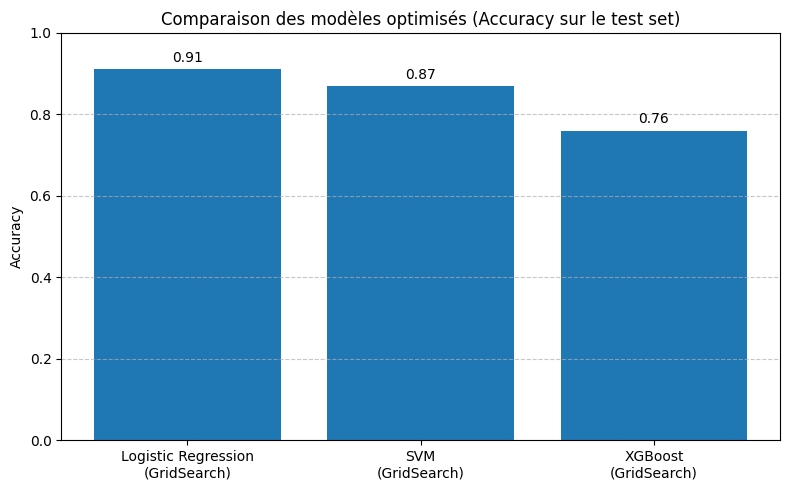

In [11]:
import matplotlib.pyplot as plt

# Noms des modèles optimisés
models = ['Logistic Regression\n(GridSearch)', 'SVM\n(GridSearch)', 'XGBoost\n(GridSearch)']

# Accuracy observées dans les résultats que tu as fournis
accuracies = [0.91, 0.87, 0.76]

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

# Ajouter les valeurs sur chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

# Titres et labels
plt.ylim(0, 1)
plt.title("Comparaison des modèles optimisés (Accuracy sur le test set)")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [12]:
!git add . 
!git commit -m "Enregistrement du dataset traité"
!git push origin main

[main 7e75243] Enregistrement du dataset traité
 3 files changed, 1467 insertions(+)
 create mode 100644 S4/J3/Exp.ipynb
 create mode 100644 S4/J3/Heart Disease Prediction Dataset.zip
 create mode 100644 S4/J3/Heart Disease Prediction Dataset/dataset_heart.csv


To https://github.com/ID18030104/AI-exercises-checker.git
   47accba..7e75243  main -> main
